In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [2]:
wine = load_wine()
X = wine.data
y = wine.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (178, 13)
Target shape: (178,)


In [3]:
models = []
models.append(("LogReg", Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=200))])))
models.append(("KNN", Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])))
models.append(("SVM", Pipeline([('scaler', StandardScaler()), ('clf', SVC())])))
models.append(("DecisionTree", DecisionTreeClassifier()))
models.append(("RandomForest", RandomForestClassifier()))


In [4]:
results = []
names = []

for name, model in models:
    cv_score = cross_val_score(model, X, y, cv=10, scoring='accuracy')
    results.append(cv_score)
    names.append(name)
    print(f"{name}: {cv_score.mean():.4f} (+/- {cv_score.std():.4f})")


LogReg: 0.9833 (+/- 0.0255)
KNN: 0.9660 (+/- 0.0278)
SVM: 0.9778 (+/- 0.0272)
DecisionTree: 0.8650 (+/- 0.1040)
RandomForest: 0.9722 (+/- 0.0278)


/tmp/ipython-input-4002911881.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names)


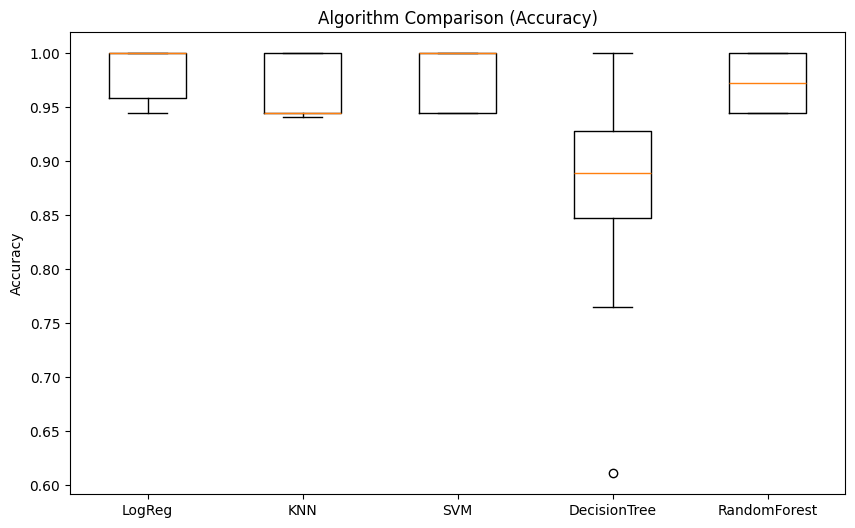

In [5]:
plt.figure(figsize=(10,6))
plt.boxplot(results, labels=names)
plt.title("Algorithm Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.show()


In [6]:
best_index = np.argmax([np.mean(r) for r in results])
best_model_name = names[best_index]
best_accuracy = np.mean(results[best_index])

print("Best Model:", best_model_name)
print("Best Mean Accuracy:", best_accuracy)


Best Model: LogReg
Best Mean Accuracy: 0.9833333333333332
